# Loading libraries and data

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# for normalization, standardization
from sklearn import preprocessing

# import a library for working with encoders
import category_encoders as ce

# import the Counter object from the collections module
from collections import Counter

# import the SentimentIntensityAnalyzer class from the nltk library
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.downloader.download('vader_lexicon')

# download a special convenient tool for splitting the dataset
from sklearn.model_selection import train_test_split

# libraries for significance assessment
from sklearn.feature_selection import chi2       # chi-square
from sklearn.feature_selection import f_classif  # anova

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/azudilins/nltk_data...


In [ ]:
# always fix RANDOM_SEED to make your experiments reproducible!
RANDOM_SEED = 42

In [ ]:
# Let's lock the package version so that experiments are reproducible:
!pip freeze > requirements.txt

In [ ]:
# Let's load our data from the competition

DATA_DIR = '/home/azudilins/Documents/Data/'
df_train = pd.read_csv(DATA_DIR+'hotels_train.csv')         # training dataset
df_test = pd.read_csv(DATA_DIR+'hotels_test.csv')           # dataset for prediction
sample_submission = pd.read_csv(DATA_DIR+'submission.csv')  # submission

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [8]:
df_train.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [10]:
df_test.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443


In [11]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


In [12]:
sample_submission.head(2)

,reviewer_score,id
0,1,488440
1,10,274649


In [ ]:
# IMPORTANT! To correctly process features, combine the train and test into one dataset.
df_train['sample'] = 1                                             # mark where our train is
df_test['sample'] = 0                                              # mark where our test is

# in the test we don't have a reviewer_score value, we have to predict it, so for now we just fill it with zeros
df_test['reviewer_score'] = 0 

data = df_test.append(df_train, sort=False).reset_index(drop=True) # unite

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515738 non-null  object 
 1   additional_number_of_scoring                515738 non-null  int64  
 2   review_date                                 515738 non-null  object 
 3   average_score                               515738 non-null  float64
 4   hotel_name                                  515738 non-null  object 
 5   reviewer_nationality                        515738 non-null  object 
 6   negative_review                             515738 non-null  object 
 7   review_total_negative_word_counts           515738 non-null  int64  
 8   total_number_of_reviews                     515738 non-null  int64  
 9   positive_review                             515738 non-null  object 
 

# Creating new features

#### 1. Working with the 'hotel_address' column

In [ ]:
# let's see what information the 'hotel_address' column contains
list(data['hotel_address'].unique())[:10]

['Via Senigallia 6 20161 Milan Italy',
 'Arlandaweg 10 Westpoort 1043 EW Amsterdam Netherlands',
 'Mallorca 251 Eixample 08008 Barcelona Spain',
 'Piazza Della Repubblica 17 Central Station 20124 Milan Italy',
 'Singel 303 309 Amsterdam City Center 1012 WJ Amsterdam Netherlands',
 'Coram Street Camden London WC1N 1HT United Kingdom',
 'Empire Way Wembley Brent London HA9 8DS United Kingdom',
 '1 Shortlands Hammersmith and Fulham London W6 8DR United Kingdom',
 '35 Rue Caumartin 9th arr 75009 Paris France',
 '49 Gloucester Place Marble Arch Westminster Borough London W1U 8JE United Kingdom']

In [ ]:
# create a function to extract the city from the address
def get_city(address):
    address_list = address.split(' ')
    if address_list[-2] == 'United' and address_list[-1] == 'Kingdom':
        return address_list[-5]
    else:
        return address_list[-2]

# create a function to extract the country from the address
def get_country(address):
    address_list = address.split(' ')
    if address_list[-2] == 'United' and address_list[-1] == 'Kingdom':
        return address_list[-2] + ' ' + address_list[-1]
    else:
        return address_list[-1]

# create columns with names of cities and countries
data['city'] = data['hotel_address'].apply(get_city)
data['country'] = data['hotel_address'].apply(get_country)

# check the received data
print('Cities:', data['city'].unique())
print('Countries:', data['country'].unique())

Cities: ['Milan' 'Amsterdam' 'Barcelona' 'London' 'Paris' 'Vienna']
Countries: ['Italy' 'Netherlands' 'Spain' 'United Kingdom' 'France' 'Austria']


In [ ]:
# we extract information from Wikipedia about the population and area of ​​our cities and countries
city_data = pd.DataFrame({
    'city': ['Milan', 'Amsterdam', 'Barcelona', 'London', 'Paris', 'Vienna'],
    'city_population': [1378689, 872757, 1636732, 8961989, 2148327, 1897491],
    'city_area': [181.67, 219.4, 101.3, 1602, 105.4, 414.75]
})
country_data = pd.DataFrame({
    'country': ['Italy', 'Netherlands', 'Spain', 'United Kingdom', 'France', 'Austria'],
    'country_population': [59236213, 17665300, 46552504, 67081000, 68084217, 8923507],
    'country_area': [302073, 41543, 505990, 242495, 643801, 83879]
})

# add columns with population density
city_data['city_density'] = (city_data['city_population'] / city_data['city_area']).astype('int')
country_data['country_density'] = (country_data['country_population'] / country_data['country_area']).astype('int')

# add the obtained data to the hotel dataset
data = data.join(city_data.set_index('city'), on = 'city')
data = data.join(country_data.set_index('country'), on = 'country')

In [ ]:
# Let's create an additional column to indicate whether the hotel is located in the capital
capitals = ['Amsterdam', 'London', 'Paris', 'Vienna']
data['is_capital'] = data['city'].apply(lambda x: 1 if x in capitals else 0)

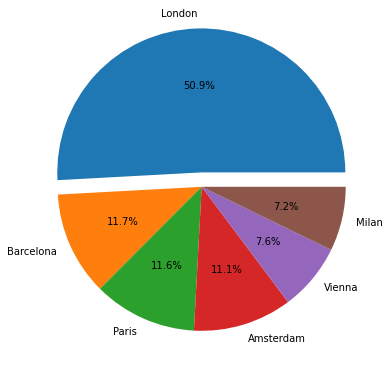

In [ ]:
# visualize the distribution of data by city
city_data = data['city'].value_counts()
fig = plt.figure(figsize=(5, 5))
axes = fig.add_axes([0, 0, 1, 1])
axes.pie(
    city_data,
    labels = city_data.index,
    autopct = '%.1f%%',
    explode = [0.1, 0, 0, 0, 0, 0]
);

#### 2. Working with the 'review_date' column

In [ ]:
# convert the date column to datetime format
data['review_date'] = pd.to_datetime(data['review_date'])

# extract the day of the week from the date
data['day_of_week'] = data['review_date'].dt.dayofweek

# extract the month from the date
data['month'] = data['review_date'].dt.month

In [ ]:
# create and use a function to extract the season
def get_season(date):
    if date.month in [1, 2, 12]:
        return 'winter'
    if date.month in [3, 4, 5]:
        return 'spring'
    if date.month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'
data['season'] = data['review_date'].apply(get_season)

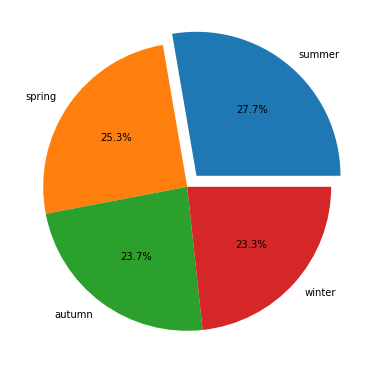

In [ ]:
# visualize the distribution of data by season
season_data = data['season'].value_counts()
fig = plt.figure(figsize=(5, 5))
axes = fig.add_axes([0, 0, 1, 1])
axes.pie(
    season_data,
    labels = season_data.index,
    autopct = '%.1f%%',
    explode = [0.1, 0, 0, 0]
);

#### 3. Working with the 'hotel_name' column

In [ ]:
# Let's look for the most useful words in hotel names
words = []
for hotel in data['hotel_name'].values:
    words.extend(hotel.split(' '))

# create a Counter object and pass the received words to it for counting
word_counts = Counter(words)

# using the most_common() method I observe the most popular words
word_counts.most_common()[:10]

[('Hotel', 234378),
 ('London', 137227),
 ('The', 58053),
 ('Park', 43929),
 ('Amsterdam', 39868),
 ('Hilton', 35490),
 ('by', 24369),
 ('Plaza', 23105),
 ('Paris', 21792),
 ('Grand', 18430)]

In [ ]:
# let's choose 15 words that, in my opinion, can influence something
words_to_apply = [
    'park', 'hilton', 'plaza', 'grand', 'inn', 'city', 'holiday', 'western',
    'palace', 'radisson', 'blu', 'mercure', 'tower', 'paddington', 'novotel'
]

# we iterate over the selected words and create indicator columns indicating whether the hotels contain these words in their names
for word in words_to_apply:
    data[word + '_hotel'] = data['hotel_name'].apply(
        lambda x: 1 if word in x.lower() else 0
    )

#### 4. Working with the 'reviewer_nationality' column

In [ ]:
# first, let's clear the values ​​of extra spaces
data['reviewer_nationality'] = data['reviewer_nationality'].apply(lambda x: x.strip())

# We indicate whether the reviewer is a citizen of the country in which the hotel is located
data['is_citizen'] = data['reviewer_nationality'] == data['country']
data['is_citizen'] = data['is_citizen'].astype('int')

# we'll leave only the 15 most popular nationalities in the list, and fill the rest with the value 'other'
top_nations = list(data['reviewer_nationality'].value_counts()[:15].index)
data['reviewer_nationality'] = data['reviewer_nationality'].apply(lambda x: x if x in top_nations else 'other')

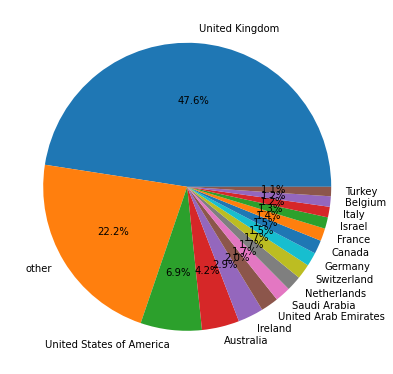

In [ ]:
# visualizing the distribution of data by citizenship
reviewer_data = data['reviewer_nationality'].value_counts()
fig = plt.figure(figsize=(5, 5))
axes = fig.add_axes([0, 0, 1, 1])
axes.pie(
    reviewer_data,
    labels = reviewer_data.index,
    autopct = '%.1f%%'
);

#### 5. Working with the 'negative_review' and 'positive_review' columns

In [ ]:
# let's look at the most popular reviews
display(data['negative_review'].value_counts()[:10])
print() # отступ
display(data['positive_review'].value_counts()[:10])

No Negative    127890
 Nothing        14295
 Nothing         4236
 nothing         2225
 N A             1037
 None             984
                  849
 N a              509
 Breakfast        407
 Small room       373
Name: negative_review, dtype: int64

No Positive        35946
 Location           9222
 Everything         2284
 location           1677
 Nothing            1243
 The location       1126
 Great location     1047
 Good location       927
 Location            915
 Everything          613
Name: positive_review, dtype: int64

To express negative and positive reviews in numerical format, we'll use the SentimentIntensityAnalyzer class from the nltk library. For it to work correctly, some transformations are required in our dataset values.

In [ ]:
# remove extra spaces and convert all characters to lowercase
data['negative_review'] = data['negative_review'].apply(
    lambda x: x.strip().lower()
)
data['positive_review'] = data['positive_review'].apply(
    lambda x: x.strip().lower()
)

# the absence of reviews that give emotional coloring is filled with blank lines
not_negative = [
    'no negative', 'no complaints', 'nothing all good', 'having to leave',
    'nothing it was perfect', 'nothing everything was perfect',
    'there was nothing i didn t like', 'no'
]
not_positive = ['no positive']

data['negative_review'] = data['negative_review'].apply(
    lambda x: '' if x in not_negative else x
)
data['positive_review'] = data['positive_review'].apply(
    lambda x: '' if x in not_positive else x
)

# popular values ​​that have emotional connotations depending on which column
# they are in are supplemented with a suffix in accordance with the column name
real = [
    'location', 'the location', 'everything', 'small room', 'breakfast',
    'price', 'small rooms', 'staff', 'location and staff', 'location staff',
    'location location location', 'comfy bed', 'expensive', 'room size',
    'expensive breakfast', 'the price', 'the staff', 'all', 'every thing',
    'cleanliness', 'location breakfast', 'location only', 'wifi', 'pillows',
    'parking', 'size of room', 'the breakfast', 'breakfast too expensive',
    'central location', 'staff and location', 'the bed', 'convenient location',
    'position', 'location and breakfast'
]

data['positive_review'] = data['positive_review'].apply(
    lambda x: x + ' positive' if x in real else x
)
data['negative_review'] = data['negative_review'].apply(
    lambda x: x + ' negative' if x in real else x
)

In [ ]:
# create the SentimentIntensityAnalyzer class
sent_analyzer = SentimentIntensityAnalyzer()

# create columns with numeric expressions of reviews
data['negative_neg'] = data['negative_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['neg']
)
data['negative_neu'] = data['negative_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['neu']
)
data['negative_pos'] = data['negative_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['pos']
)
data['negative_compound'] = data['negative_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['compound']
)
data['positive_neg'] = data['positive_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['neg']
)
data['positive_neu'] = data['positive_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['neu']
)
data['positive_pos'] = data['positive_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['pos']
)
data['positive_compound'] = data['positive_review'].apply(
    lambda x: sent_analyzer.polarity_scores(x)['compound']
)

#### 6. Working with the 'tags' column

In [ ]:
# create a complete list of tags
tags = []
for tag_list in data['tags'].values:
    tag_list = tag_list.replace("[' ", "")
    tag_list = tag_list.replace(" ']", "")
    tag_list = tag_list.split(" ', ' ")
    tags.extend(tag_list)

# count the number of tags using the Counter class
tag_counter = Counter(tags)
sorted_tags = list(tag_counter.most_common())
sorted_tags[:10]

[('Leisure trip', 417778),
 ('Submitted from a mobile device', 307640),
 ('Couple', 252294),
 ('Stayed 1 night', 193645),
 ('Stayed 2 nights', 133937),
 ('Solo traveler', 108545),
 ('Stayed 3 nights', 95821),
 ('Business trip', 82939),
 ('Group', 65392),
 ('Family with young children', 61015)]

In [ ]:
# create a function and extract the number of nights spent in the hotel
def get_stayed_nights(tags):
    tags_list = tags.split(' ')
    if 'Stayed' in tags_list:
        night_index = tags_list.index('Stayed') + 1
        return int(tags_list[night_index])
    else:
        return np.NaN

data['stayed_nights'] = data['tags'].apply(get_stayed_nights)


# We'll add another 15 columns to the dataset to indicate the most popular tags.
new_columns = []

for tag, count in sorted_tags:
    if 'Stayed' not in tag:
        new_columns.append(tag)    
        
for column in new_columns[:15]:
    data[column] = data['tags'].apply(lambda x: 1 if column in x else 0)

#### 7. Working with the 'days_since_review' column

In [ ]:
# split the column by space and leave only the numeric part of the data
data['days_since_review'] = data['days_since_review'].apply(
    lambda x: int(x.split(' ')[0])
)

#### 8. Coding of features

In [ ]:
# Nominal features containing no more than 16 unique values ​​are encoded using the OneHotEncoding class.
encoder = ce.OneHotEncoder(
    cols = ['city', 'day_of_week', 'month', 'season', 'reviewer_nationality']
)
data_bin = encoder.fit_transform(
    data[['city', 'day_of_week', 'month', 'season', 'reviewer_nationality']]
)
data = pd.concat([data, data_bin], axis = 1)

# Clearing missing values

In [ ]:
# fill in the gaps in the geographic coordinates with a modal value depending on the city
data['lat'] = data['lat'].fillna(
    data.groupby(['city'])['lat'].transform(lambda x: x.mode()[0])
)
data['lng'] = data['lng'].fillna(
    data.groupby(['city'])['lng'].transform(lambda x: x.mode()[0])
)

# missing values ​​in the 'stayed_nights' column are filled with a modal value
data['stayed_nights'].fillna(data['stayed_nights'].mode()[0], inplace=True)
# and replace the data type with 'int'
data['stayed_nights'] = data['stayed_nights'].astype('int')

# Removing string values

In [ ]:
# remove features that haven't been processed yet, the model won't be
# trained on features with "object" dtypes, just select them and remove them
object_columns = [s for s in data.columns if data[s].dtypes == 'object']
data.drop(object_columns, axis = 1, inplace = True)

# remove the datetime column
data.drop('review_date', axis = 1, inplace = True)

# remove the 'day_of_week' and 'month' columns, which are already encoded as categorical
data = data.drop(['day_of_week', 'month'], axis = 1)

# Transformation of features

Since we have a lot of binary features (with a value of 0 or 1), it would be logical to bring the remaining features into this range.

In [ ]:
# save the columns that will be transformed
col_names = []
for col in data.columns:
    if (data[col].min() < 0 or data[col].max() > 1) and col != 'reviewer_score':
        col_names.append(col)

# output the obtained result
print('Columns to convert:')
for col in col_names:
    print(col)

Columns to convert:
additional_number_of_scoring
average_score
review_total_negative_word_counts
total_number_of_reviews
review_total_positive_word_counts
total_number_of_reviews_reviewer_has_given
days_since_review
lat
lng
city_population
city_area
city_density
country_population
country_area
country_density
negative_compound
positive_compound
stayed_nights


In [ ]:
# initialize the MinMaxScaler normalizer
mm_scaler = preprocessing.MinMaxScaler()

# create normalized columns
data_mm = mm_scaler.fit_transform(data[col_names])

# transform the intermediate dataset into a full-fledged dataframe
data_mm = pd.DataFrame(data_mm, columns = col_names)

# remove transformed columns from the original dataset
data = data.drop(col_names, axis = 1)

# combining data
data = pd.concat([data_mm, data], axis = 1)

# Feature selection

#### 1. Multicollinearity analysis

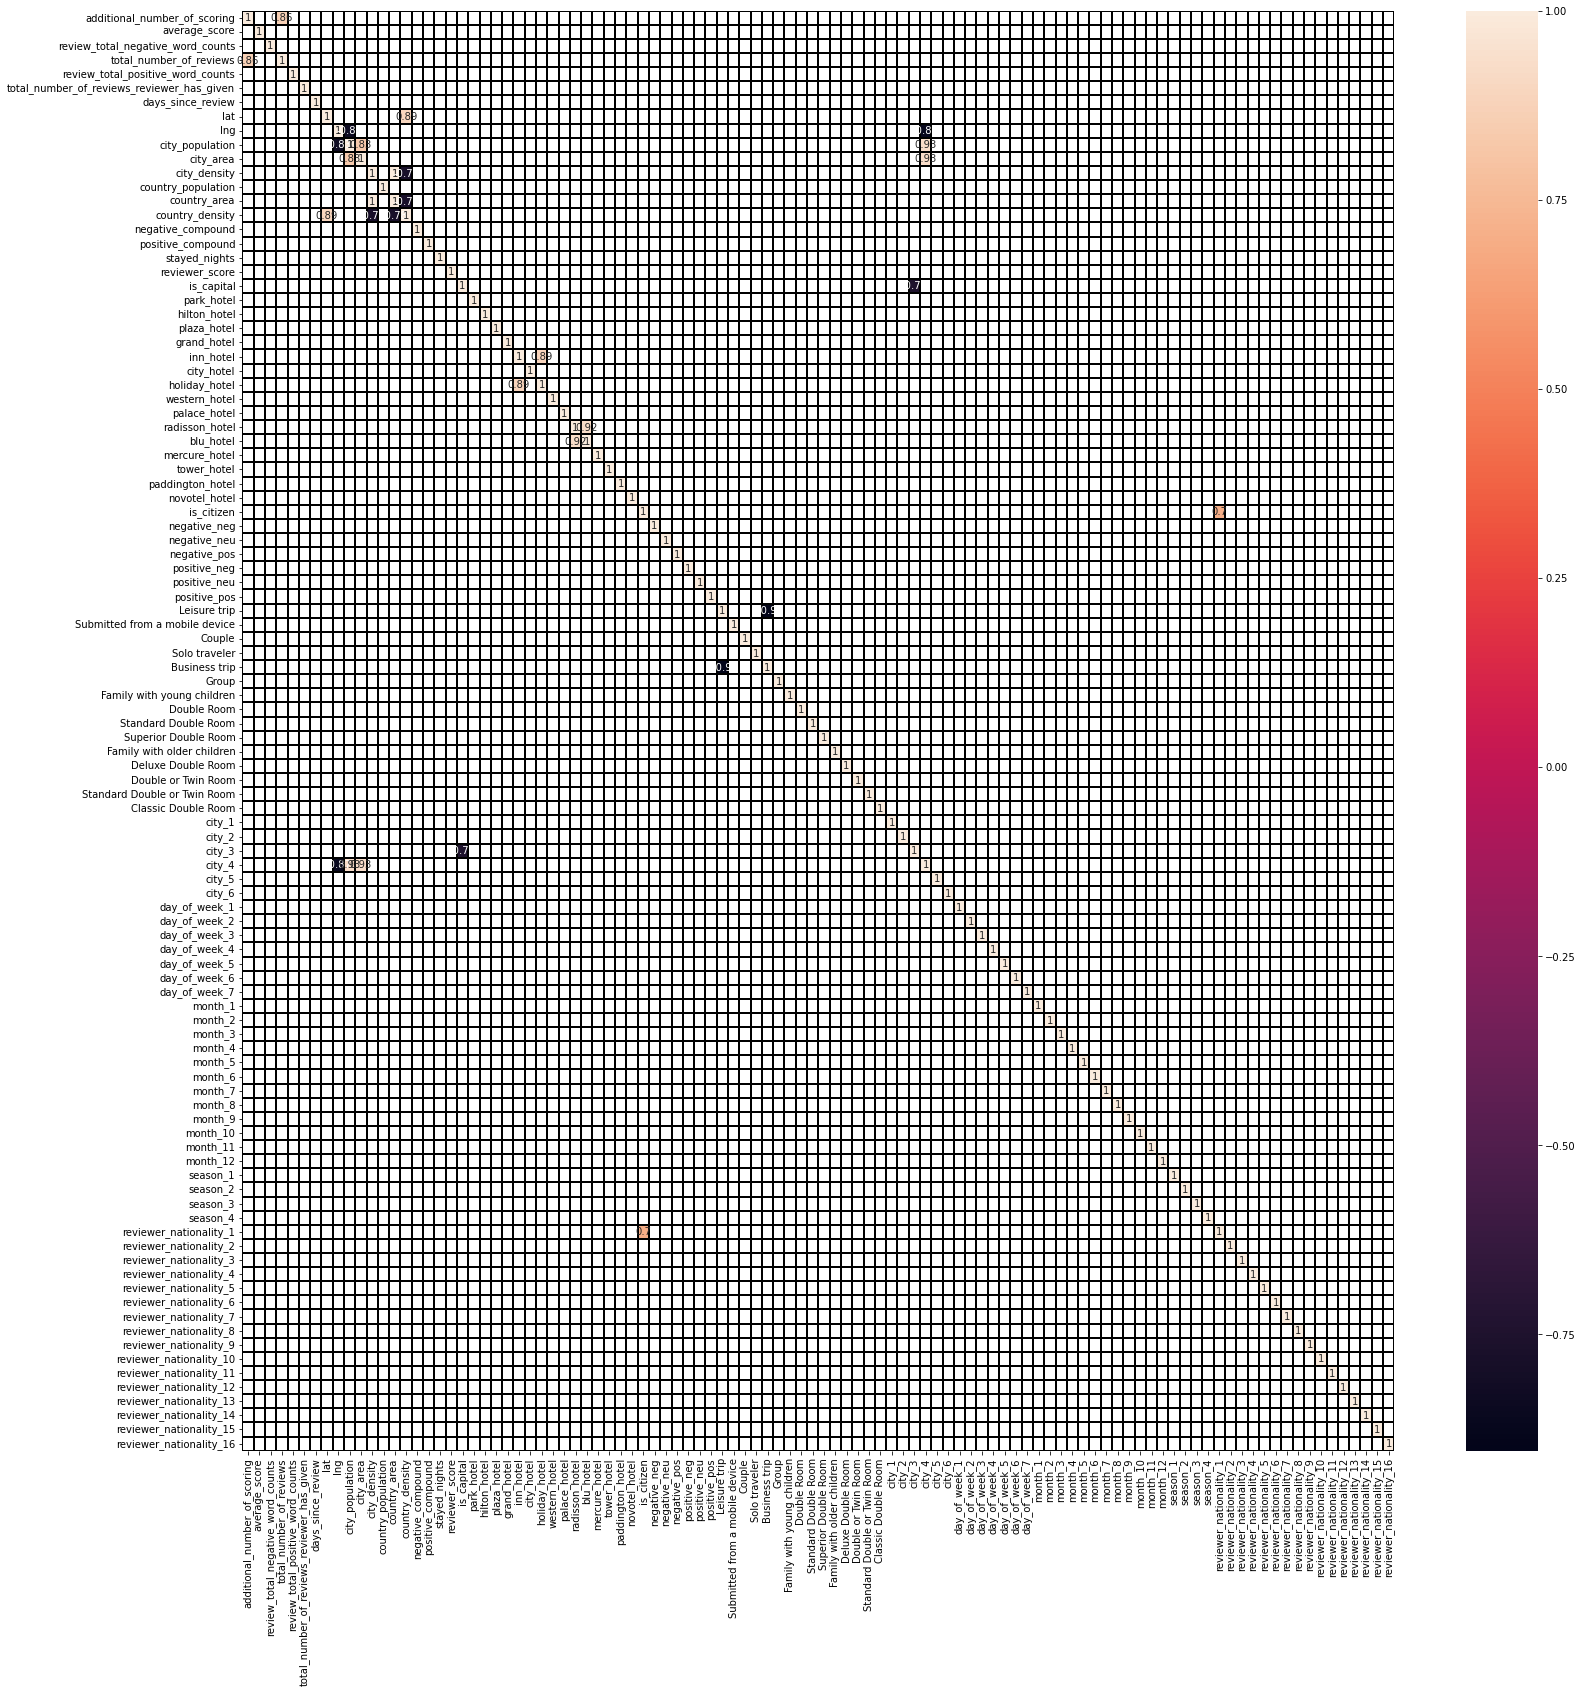

In [ ]:
# for correlation with categorical features we will use Spearman's method
corr = data.drop(['sample'], axis=1).corr(method = 'spearman')

# display only data with a high correlation level
mask_1 = np.abs(corr) >= 0.70
mask_2 = np.abs(corr) <= -0.70
corr_data = corr[mask_1 | mask_2]

fig = plt.figure(figsize=(20, 20))
axes = fig.add_axes([0, 0, 1, 1])
sns.heatmap(corr_data, annot=True, ax=axes, linewidth=0.3, linecolor='black');

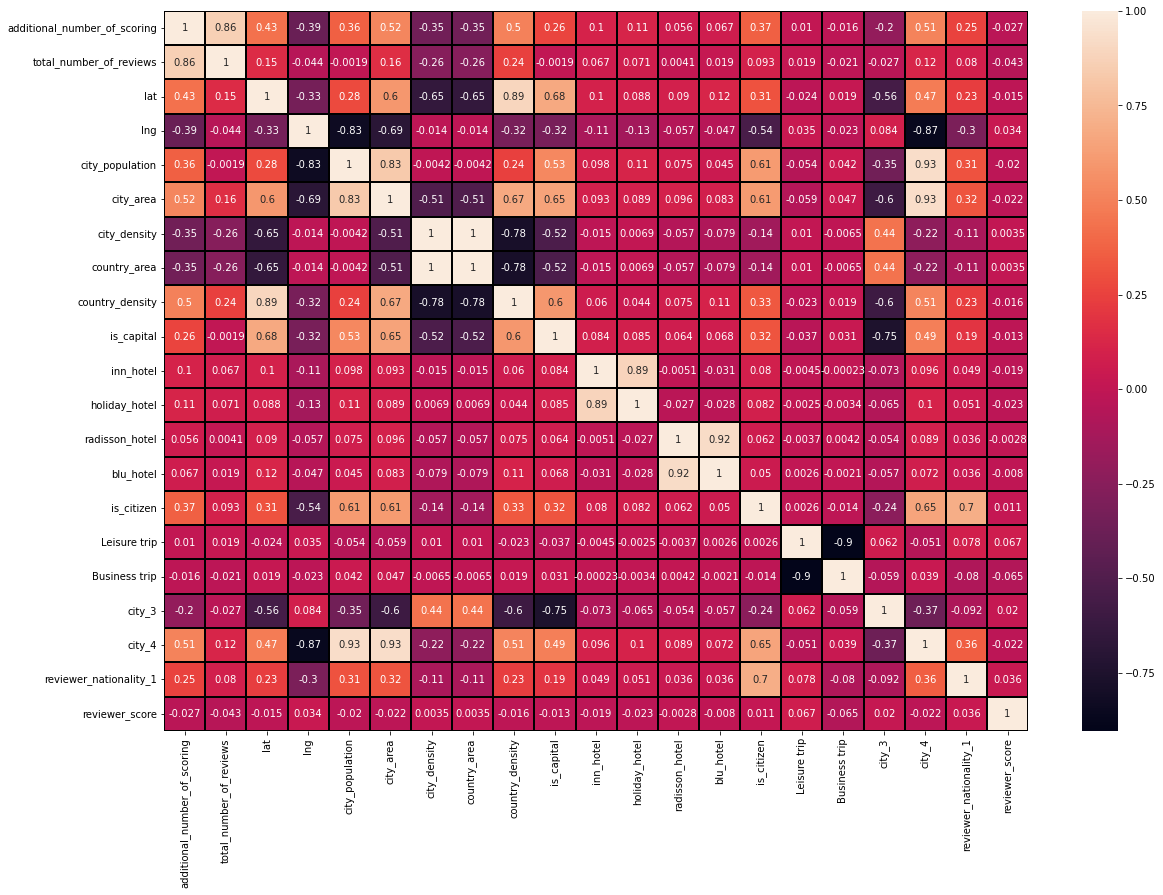

In [ ]:
# To understand which features to remove, let's look at how they correlate with the target feature 'reviewer_score'
corr = data[[
    'additional_number_of_scoring', 'total_number_of_reviews', 'lat', 'lng',
    'city_population', 'city_area', 'city_density', 'country_area',
    'country_density', 'is_capital', 'inn_hotel', 'holiday_hotel',
    'radisson_hotel', 'blu_hotel', 'is_citizen', 'Leisure trip',
    'Business trip', 'city_3', 'city_4', 'reviewer_nationality_1',
    'reviewer_score'
]].corr(method = 'spearman')

fig = plt.figure(figsize=(15, 10))
axes = fig.add_axes([0, 0, 1, 1])
sns.heatmap(corr, annot=True, ax=axes, linewidth=0.3, linecolor='black');

In [ ]:
# remove those features that are less correlated with the target feature
data = data.drop([
    'radisson_hotel', 'city_density', 'country_area', 'is_citizen',
    'is_capital', 'lat', 'inn_hotel', 'city_population', 'city_4',
    'additional_number_of_scoring', 'Business trip'
], axis = 1)

#### 2. Evaluation of the significance of features

In [ ]:
# split the data frame into parts necessary for assessing significance
# X - data with information about hotels, y - target variable (hotel ratings)
X = data.drop(['reviewer_score'], axis = 1)
y = data['reviewer_score'].astype('int')

# we divide features into continuous and categorical
num_cols = [
    'average_score', 'review_total_negative_word_counts',
    'total_number_of_reviews', 'review_total_positive_word_counts',
    'total_number_of_reviews_reviewer_has_given', 'days_since_review',
    'city_area', 'country_population', 'country_density', 'negative_compound',
    'positive_compound', 'stayed_nights', 'negative_neg', 'negative_neu',
    'negative_pos', 'positive_neg', 'positive_neu', 'positive_pos'
]
cat_cols = [
    'lng', 'park_hotel', 'hilton_hotel', 'plaza_hotel',
    'grand_hotel', 'city_hotel', 'holiday_hotel', 'western_hotel',
    'palace_hotel', 'blu_hotel', 'mercure_hotel',
    'tower_hotel', 'paddington_hotel', 'novotel_hotel',
    'Leisure trip', 'Submitted from a mobile device', 'Couple',
    'Solo traveler', 'Group', 'Family with young children',
    'Double Room', 'Standard Double Room', 'Superior Double Room',
    'Family with older children', 'Deluxe Double Room', 'Double or Twin Room',
    'Standard Double or Twin Room', 'Classic Double Room', 'city_1', 'city_2',
    'city_3', 'city_5', 'city_6', 'day_of_week_1', 'day_of_week_2',
    'day_of_week_3', 'day_of_week_4', 'day_of_week_5', 'day_of_week_6',
    'day_of_week_7', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5',
    'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11',
    'month_12', 'season_1', 'season_2', 'season_3', 'season_4',
    'reviewer_nationality_1', 'reviewer_nationality_2',
    'reviewer_nationality_3', 'reviewer_nationality_4',
    'reviewer_nationality_5', 'reviewer_nationality_6',
    'reviewer_nationality_7', 'reviewer_nationality_8',
    'reviewer_nationality_9', 'reviewer_nationality_10',
    'reviewer_nationality_11', 'reviewer_nationality_12',
    'reviewer_nationality_13', 'reviewer_nationality_14',
    'reviewer_nationality_15', 'reviewer_nationality_16'
]

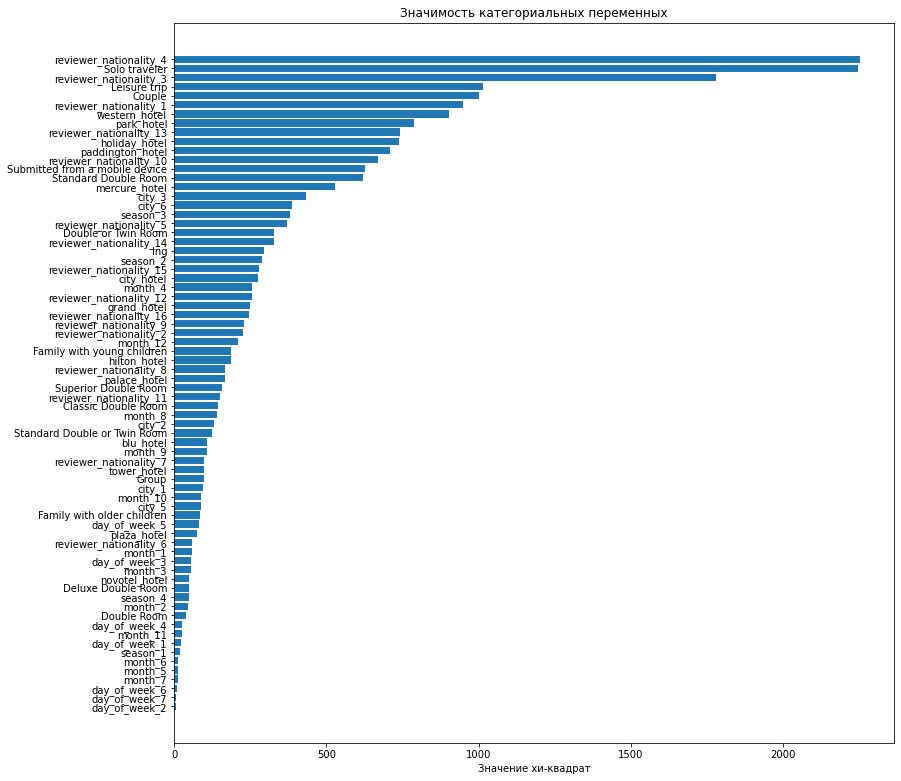

In [ ]:
# to assess the significance of categorical variables we will use the nonparametric chi-square test
imp_cat = pd.Series(chi2(X[cat_cols], y)[0], index = cat_cols)
imp_cat.sort_values(inplace = True)

# visualize the obtained results
fig = plt.figure(figsize=(10, 10))
axes = fig.add_axes([0, 0, 1, 1])
axes.barh(imp_cat.index, imp_cat)
axes.set_title('Значимость категориальных переменных')
axes.set_xlabel('Значение хи-квадрат');

In [ ]:
# we will leave only the most significant half of the categorical features
cols_to_drop = imp_cat[imp_cat.values < imp_cat.median()]
data = data.drop(cols_to_drop.index, axis = 1)

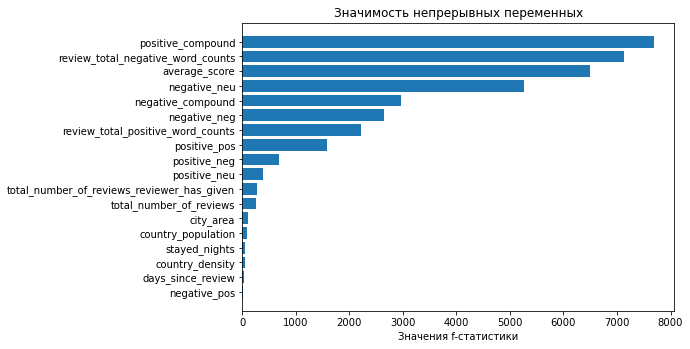

In [ ]:
# to evaluate the significance of continuous variables we will use the f_classif function
imp_num = pd.Series(f_classif(X[num_cols], y)[0], index = num_cols)
imp_num.sort_values(inplace = True)

# visualize the obtained results
fig = plt.figure()
axes = fig.add_axes([0, 0, 1, 1])
axes.barh(imp_num.index, imp_num)
axes.set_title('Значимость непрерывных переменных')
axes.set_xlabel('Значения f-cтатистики');

In [ ]:
# we will leave only the most significant half of the numerical features
cols_to_drop = imp_num[imp_num.values < imp_num.median()]
data = data.drop(cols_to_drop.index, axis = 1)

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 47 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   average_score                      515738 non-null  float64
 1   review_total_negative_word_counts  515738 non-null  float64
 2   review_total_positive_word_counts  515738 non-null  float64
 3   lng                                515738 non-null  float64
 4   negative_compound                  515738 non-null  float64
 5   positive_compound                  515738 non-null  float64
 6   sample                             515738 non-null  int64  
 7   reviewer_score                     515738 non-null  float64
 8   park_hotel                         515738 non-null  int64  
 9   hilton_hotel                       515738 non-null  int64  
 10  grand_hotel                        515738 non-null  int64  
 11  city_hotel                         5157

# Machine learning stage

In [ ]:
# Now let's select the test part
train_data = data.query('sample == 1').drop(['sample'], axis=1)
test_data = data.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values  # our target
X = train_data.drop(['reviewer_score'], axis=1)

In [ ]:
# We will use the special function train_test_split to split the test data
# allocate 20% of the data for validation (test_size parameter)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [ ]:
# checking
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 46), (386803, 46), (386803, 45), (309442, 45), (77361, 45))

In [ ]:
# Import the necessary libraries:
from sklearn.ensemble import RandomForestRegressor  # tool for creating and training a model
from sklearn import metrics                         # tools for assessing model accuracy

In [ ]:
# Create a model (DO NOT TOUCH THE SETTINGS)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [ ]:
# Train the model on the test dataset
model.fit(X_train, y_train)

# We use the trained model to predict the rating of hotels in the test sample.
# We write the predicted values ​​into the variable y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 20.4min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    8.7s finished


In [ ]:
# We compare the predicted values ​​(y_pred) with the actual ones (y_test), and see how much they differ on average.
# The metric is called Mean Absolute Error (MAE) and shows the average deviation of predicted values ​​from actual ones.
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))

MAE: 0.8755444773431906


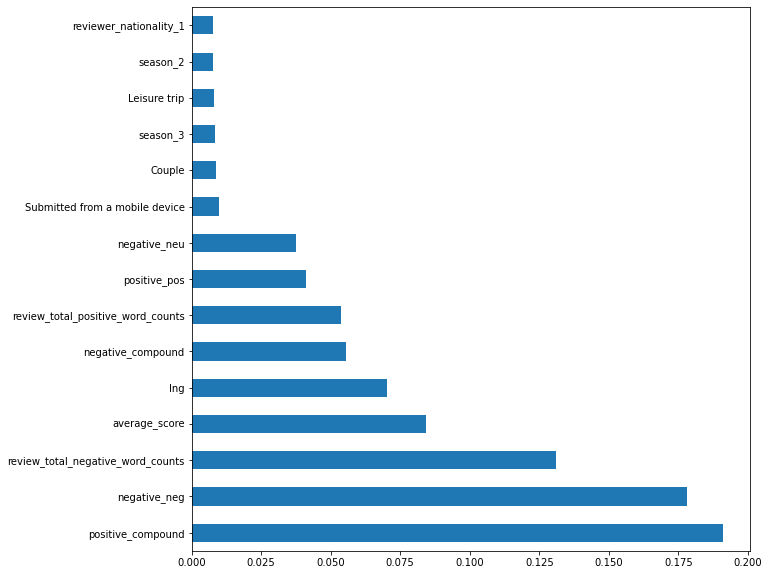

In [ ]:
# RandomForestRegressor has the ability to extract the most important features for the model
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh');

In [55]:
test_data.sample(10)

,average_score,review_total_negative_word_counts,review_total_positive_word_counts,lng,negative_compound,positive_compound,reviewer_score,park_hotel,hilton_hotel,grand_hotel,...,reviewer_nationality_4,reviewer_nationality_5,reviewer_nationality_8,reviewer_nationality_9,reviewer_nationality_10,reviewer_nationality_12,reviewer_nationality_13,reviewer_nationality_14,reviewer_nationality_15,reviewer_nationality_16
112177,0.717391,0.007353,0.000000,0.566257,0.228567,0.495964,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31019,0.826087,0.000000,0.030380,0.013076,0.500451,0.744502,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
26164,0.630435,0.105392,0.020253,0.010599,0.504262,0.324455,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21273,0.673913,0.022059,0.048101,0.570352,0.500451,0.896439,0.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
63701,0.695652,0.019608,0.020253,0.015105,0.612754,0.678168,0.0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
21698,0.804348,0.000000,0.007595,0.009901,0.500451,0.495964,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31039,0.652174,0.014706,0.000000,0.012685,0.500451,0.495964,0.0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
41370,0.565217,0.049020,0.027848,0.151701,0.786674,0.880851,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
104375,0.739130,0.046569,0.058228,0.150996,0.500451,0.972609,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
77762,0.717391,0.034314,0.015190,0.015684,0.228567,0.495964,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [57]:
sample_submission

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596
...,...,...
128930,7,495812
128931,1,315577
128932,3,511968
128933,6,303386


In [58]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   11.3s finished


In [59]:
predict_submission

array([8.663, 7.9  , 8.214, ..., 8.048, 9.553, 7.326])

In [60]:
list(sample_submission)

['reviewer_score', 'id']

In [61]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.663,488440
1,7.900,274649
2,8.214,374688
3,9.708,404352
4,9.677,451596
5,8.717,302161
6,7.476,317079
7,7.743,13963
8,8.232,159785
9,7.419,195089
